# Daikibo Telemetry — Down Time Analysis

**Author:** Ritika Mishra
**Project:** IBM SkillsBuild Data Analytics with AI Internship — BharatCares / AICTE

**Business questions**
1. In which location did machines break the most?
2. What are the machines that broke most often in that location?

**Dataset:** `daikibo-telemetry-data.json` — telemetry from 4 Daikibo factories (Meiyo/Tokyo, Seiko/Osaka, Berlin, Shenzhen), 9 machine types per factory, one reading every 10 minutes, for May 2021.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 1. Load and flatten the data

In [2]:
with open('daikibo-telemetry-data.json') as f:
    raw = json.load(f)

df = pd.json_normalize(raw)
df.rename(columns={
    'location.country': 'country',
    'location.city': 'city',
    'location.area': 'area',
    'location.factory': 'factory',
    'location.section': 'section',
    'data.status': 'status',
    'data.temperature': 'temperature'
}, inplace=True)
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

print(f"Rows: {len(df):,}   Factories: {df['factory'].nunique()}   Device types: {df['deviceType'].nunique()}")
df.head()

Rows: 160,704   Factories: 4   Device types: 9


,deviceID,deviceType,timestamp,country,city,area,factory,section,status,temperature
0,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:00:00,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,27
1,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:10:00,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,27
2,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:20:00,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,26
3,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:30:00,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,24
4,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,2021-04-30 21:40:00,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,27


## 2. Data quality check

In [3]:
print(df['status'].value_counts())
print()
print(df.isna().sum())

status
healthy      160601
unhealthy       103
Name: count, dtype: int64

deviceID       0
deviceType     0
timestamp      0
country        0
city           0
area           0
factory        0
section        0
status         0
temperature    0
dtype: int64


## 3. Calculated field: `Unhealthy`

Every telemetry message represents a 10-minute interval. Each `unhealthy` reading is
counted as 10 minutes of potential down time (mirrors the calculated field built in
Tableau: `IF status = "unhealthy" THEN 10 ELSE 0 END`).

In [4]:
df['Unhealthy'] = (df['status'] == 'unhealthy').astype(int) * 10
df[['factory', 'deviceType', 'status', 'Unhealthy']].head()

,factory,deviceType,status,Unhealthy
0,daikibo-factory-meiyo,CNC,healthy,0
1,daikibo-factory-meiyo,CNC,healthy,0
2,daikibo-factory-meiyo,CNC,healthy,0
3,daikibo-factory-meiyo,CNC,healthy,0
4,daikibo-factory-meiyo,CNC,healthy,0


## 4. Down Time per Factory

In [5]:
down_time_factory = (
    df.groupby('factory')['Unhealthy'].sum()
    .sort_values(ascending=False)
)
down_time_factory

factory
daikibo-factory-seiko    480
daikibo-shenzhen         420
daikibo-factory-meiyo    110
daikibo-berlin            20
Name: Unhealthy, dtype: int64

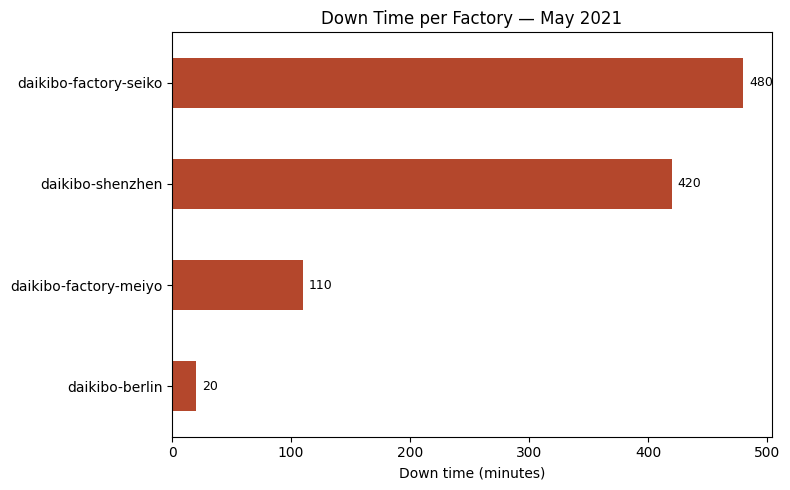

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
down_time_factory.sort_values().plot(kind='barh', ax=ax, color='#B4472C')
ax.set_xlabel('Down time (minutes)')
ax.set_ylabel('')
ax.set_title('Down Time per Factory — May 2021')
for i, v in enumerate(down_time_factory.sort_values()):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('down_time_per_factory.png', dpi=150)
plt.show()

## 5. Down Time per Device Type — in the worst factory

In [7]:
top_factory = down_time_factory.idxmax()
print(f"Factory with the most down time: {top_factory} ({down_time_factory.max()} minutes)")

down_time_device = (
    df[df['factory'] == top_factory]
    .groupby('deviceType')['Unhealthy'].sum()
    .sort_values(ascending=False)
)
down_time_device

Factory with the most down time: daikibo-factory-seiko (480 minutes)


deviceType
LaserWelder       480
AirWrench           0
CNC                 0
Furnace             0
ConveyorBelt        0
HeavyDutyDrill      0
LaserCutter         0
MetalPress          0
SpotWelder          0
Name: Unhealthy, dtype: int64

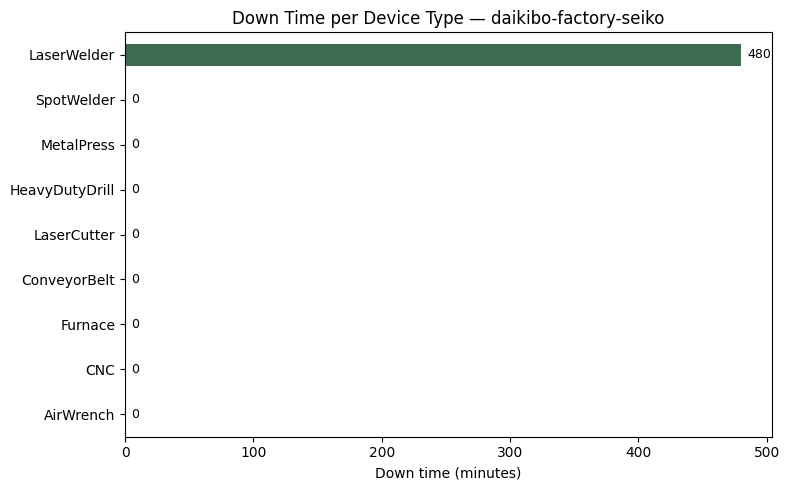

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
down_time_device.sort_values().plot(kind='barh', ax=ax, color='#3E6B52')
ax.set_xlabel('Down time (minutes)')
ax.set_ylabel('')
ax.set_title(f'Down Time per Device Type — {top_factory}')
for i, v in enumerate(down_time_device.sort_values()):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('down_time_per_device_type.png', dpi=150)
plt.show()

## 6. Findings

Run the cells above to reproduce the two headline numbers, then read them off here:

- **Which location broke the most?** The factory at the top of `down_time_factory`.
- **Which machines broke most often there?** The device type(s) at the top of `down_time_device`.

These two charts are the same "Down Time per Factory" and "Down Time per Device Type" views
built in the Tableau dashboard, with the factory chart acting as a filter for the device chart.